In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras

In [2]:
data= pd.read_csv("NKE.csv")

In [3]:
data

,Date,Close,High,Low,Open,Volume
0,1/3/2000,4.471374,4.604934,4.436532,4.581707,8014400
1,1/4/2000,4.227483,4.395886,4.215869,4.366851,9810400
2,1/5/2000,4.471374,4.494601,4.250708,4.250708,6542400
3,1/6/2000,4.448146,4.448146,4.326200,4.448146,4891200
4,1/7/2000,4.448146,4.459760,4.366849,4.430726,3993600
...,...,...,...,...,...,...
6554,1/26/2026,64.989998,65.639999,64.779999,64.809998,14765900
6555,1/27/2026,63.090000,64.830002,62.880001,64.750000,13536700
6556,1/28/2026,62.240002,63.480000,61.970001,63.049999,10363600
6557,1/29/2026,62.599998,62.939999,61.459999,61.930000,12739400


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6559 non-null   object 
 1   Close   6559 non-null   float64
 2   High    6559 non-null   float64
 3   Low     6559 non-null   float64
 4   Open    6559 non-null   float64
 5   Volume  6559 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 307.6+ KB


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data["Date"]= pd.to_datetime(data["Date"])

In [7]:
data["Year"]= data["Date"].dt.year
data["Month"]= data["Date"].dt.month
data["Day"]= data["Date"].dt.day

In [8]:
data.drop("Date", axis=1, inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6559 entries, 0 to 6558
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   6559 non-null   float64
 1   High    6559 non-null   float64
 2   Low     6559 non-null   float64
 3   Open    6559 non-null   float64
 4   Volume  6559 non-null   int64  
 5   Year    6559 non-null   int32  
 6   Month   6559 non-null   int32  
 7   Day     6559 non-null   int32  
dtypes: float64(4), int32(3), int64(1)
memory usage: 333.2 KB


In [10]:
import matplotlib.pyplot as plt

In [11]:
data.corr()

,Close,High,Low,Open,Volume,Year,Month,Day
Close,1.000000,0.999902,0.999909,0.999802,-0.254764,0.869448,0.017690,-0.000680
High,0.999902,1.000000,0.999876,0.999913,-0.252170,0.869659,0.017497,-0.000657
Low,0.999909,0.999876,1.000000,0.999902,-0.257130,0.869234,0.018260,-0.000487
Open,0.999802,0.999913,0.999902,1.000000,-0.254607,0.869325,0.017661,-0.000585
Volume,-0.254764,-0.252170,-0.257130,-0.254607,1.000000,-0.164171,0.008605,0.073781
Year,0.869448,0.869659,0.869234,0.869325,-0.164171,1.000000,-0.007294,-0.000460
Month,0.017690,0.017497,0.018260,0.017661,0.008605,-0.007294,1.000000,-0.001079
Day,-0.000680,-0.000657,-0.000487,-0.000585,0.073781,-0.000460,-0.001079,1.000000


In [12]:
from pandas.plotting import scatter_matrix

In [13]:
x= data.drop(columns=["Volume"])
y= data["Volume"].copy()

In [14]:
x,y

(          Close       High        Low       Open  Year  Month  Day
 0      4.471374   4.604934   4.436532   4.581707  2000      1    3
 1      4.227483   4.395886   4.215869   4.366851  2000      1    4
 2      4.471374   4.494601   4.250708   4.250708  2000      1    5
 3      4.448146   4.448146   4.326200   4.448146  2000      1    6
 4      4.448146   4.459760   4.366849   4.430726  2000      1    7
 ...         ...        ...        ...        ...   ...    ...  ...
 6554  64.989998  65.639999  64.779999  64.809998  2026      1   26
 6555  63.090000  64.830002  62.880001  64.750000  2026      1   27
 6556  62.240002  63.480000  61.970001  63.049999  2026      1   28
 6557  62.599998  62.939999  61.459999  61.930000  2026      1   29
 6558  61.810001  62.520000  61.020000  62.240002  2026      1   30
 
 [6559 rows x 7 columns],
 0        8014400
 1        9810400
 2        6542400
 3        4891200
 4        3993600
           ...   
 6554    14765900
 6555    13536700
 6556    103

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [16]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
x_test, x_train

(          Close       High        Low       Open  Year  Month  Day
 2481  12.956823  13.219640  12.900218  13.128666  2009     11   12
 4701  74.716835  75.026263  73.915975  74.070685  2018      9   10
 1504   8.373127   8.484654   8.358706   8.407739  2005     12   27
 2476  13.092276  13.098340  12.750614  12.835525  2009     11    5
 2627  15.134466  15.134466  14.788734  14.788734  2010      6   15
 ...         ...        ...        ...        ...   ...    ...  ...
 1480   8.295775   8.361995   8.237233   8.323607  2005     11   21
 2755  18.253914  18.464107  18.223003  18.396103  2010     12   15
 6138  88.688217  89.189495  88.061614  88.437574  2024      5   28
 2094  13.316414  13.499449  13.188485  13.499449  2008      5    2
 4760  71.141479  72.109016  70.219577  70.374747  2018     12    3
 
 [1312 rows x 7 columns],
            Close        High         Low        Open  Year  Month  Day
 4113   52.240665   52.937797   51.720024   51.720024  2016      5   10
 5084   65.0

In [18]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [19]:
x_train_scaled

array([[ 0.24407279,  0.24790303,  0.24448206, ...,  0.4494659 ,
        -0.44942261, -0.65841641],
       [ 0.56584922,  0.60343625,  0.43759694, ...,  0.98155402,
        -1.03160269,  0.36668656],
       [-0.61814939, -0.61971096, -0.62261456, ..., -0.21564425,
         0.71493756, -0.31671542],
       ...,
       [ 1.98765809,  1.96078237,  1.98014537, ...,  0.98155402,
         1.0060276 , -0.77231675],
       [ 2.07589518,  2.07227016,  2.09629977, ...,  1.11457605,
        -0.15833257, -1.00011741],
       [-0.9355049 , -0.93504507, -0.93493833, ..., -1.27982049,
        -0.15833257, -0.77231675]])

In [20]:
from keras.layers import Dense, Input, Flatten
from keras.models import Sequential

In [21]:
model= Sequential([
    Input(shape=(7,)),
    Dense(6, activation="relu"),
    Dense(4, activation="relu"),
    Dense(2, activation="relu"),
    Dense(1, activation="linear")
])

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="Adam",
    loss="mean_squared_error",
    metrics=["accuracy"]
)

In [24]:
history= model.fit(x_train_scaled, y_train, epochs=275, validation_split=0.2)

Epoch 1/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0000e+00 - loss: 173867020582912.0000 - val_accuracy: 0.0000e+00 - val_loss: 140803003383808.0000
Epoch 2/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 173866919919616.0000 - val_accuracy: 0.0000e+00 - val_loss: 140802902720512.0000
Epoch 3/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 173866785701888.0000 - val_accuracy: 0.0000e+00 - val_loss: 140802600730624.0000
Epoch 4/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 173866164944896.0000 - val_accuracy: 0.0000e+00 - val_loss: 140801677983744.0000
Epoch 5/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 173864722104320.0000 - val_accuracy: 0.0000e+00 - val_loss: 140799899598848.0000
Epoch 6/275
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0000e+00 - loss: 173862272630784.0000 - val_accuracy: 0.0000e+00 - val_loss: 140796728705024.0000
Epoch 7/27

In [25]:
y_pred= model.predict(x_test_scaled)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


In [26]:
from sklearn.metrics import r2_score

In [27]:
r2_score(y_test, y_pred)

-0.013983368873596191

In [28]:
import matplotlib.pyplot as plt

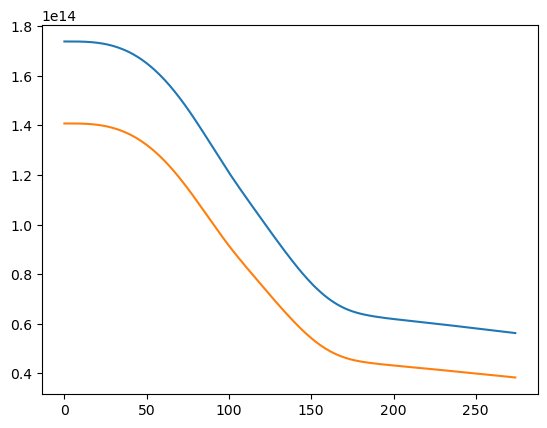

In [29]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

In [30]:
x_train_scaled.shape

(5247, 7)